# Part2 Clustering

## Data

In [1]:
import os
os.chdir('./proj1_data/')
os.getcwd()

'/home/tako/Kasetsart/statistics/project1/proj1_data'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import statsmodels.api as sm

## Data

In [3]:
Dataset = "part2_cleaned.csv"
orig_df = pd.read_csv(Dataset)
orig_df

,Country Name,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),Food production index (2014-2016 = 100),Forest area (% of land area),...,High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Region,ThirdWorld
0,Afghanistan,2017,58.12,26.42,11.80,2091.4,99.210,20.45,99.84,1.85,...,6.23,86113314.5,2.120000,7.230000e+08,7.065000e+09,41.53,62.58,12.20,South Asia,Yes
1,Albania,2017,42.86,19.02,22.34,4813.0,105.840,99.81,103.88,28.79,...,0.09,1118611.0,3.560000,2.292000e+09,5.271000e+09,58.09,29.97,17.04,Eastern Europe,No
2,Algeria,2017,17.36,11.03,3.14,990.3,104.400,20.84,102.87,0.82,...,0.96,9028313.0,3.950000,3.519100e+10,4.605900e+10,42.79,2.33,1.70,Africa,No
3,American Samoa,2017,13.90,6.59,4.65,3052.7,103.615,41.67,104.00,86.10,...,6.23,86113314.5,33.202833,3.970000e+08,5.950000e+08,162.09,4.25,1.99,Australia and Oceanea,No
4,Andorra,2017,40.04,0.56,1.74,3052.7,103.615,90.00,104.00,34.04,...,23.25,24238350.0,33.202833,1.180000e+08,1.478000e+09,53.20,4.25,1.99,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1075,Virgin Islands (U.S.),2021,9.43,6.59,2.57,3052.7,103.615,90.00,104.00,57.31,...,6.23,86113314.5,33.202833,6.608000e+09,9.121000e+09,53.03,0.34,0.21,North America,No
1076,West Bank and Gaza,2021,64.93,6.32,6.95,2251.9,117.310,371.97,117.39,1.68,...,1.60,14531924.0,15.110000,6.608000e+09,9.121000e+09,53.03,8.55,3.44,Middle East,No
1077,"Yemen, Rep.",2021,44.42,6.59,2.19,1524.8,124.710,10.63,120.77,1.04,...,6.23,86113314.5,0.250000,6.620000e+08,5.054000e+09,29.68,37.64,9.04,Middle East,Yes
1078,Zambia,2021,32.07,3.00,5.11,2525.0,136.310,63.90,127.49,60.03,...,0.95,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,Africa,Yes


## Functions

In [4]:
def remove_outliers_iqr(df, outlier_vars):
    temp_df = df.copy()
    for _var in outlier_vars:
        q1 = temp_df[_var].quantile(0.25)
        q3 = temp_df[_var].quantile(0.75)
        iqr = q3-q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        mask = (temp_df[_var] < lower_bound) | (temp_df[_var] > upper_bound)
        temp_df = temp_df[~mask]
        print(temp_df.shape)
    col_names = df.columns.tolist()
    new_df = pd.DataFrame(temp_df, col_names)
    return temp_df

In [5]:
def transform_log(X, skew_var):
    temp_X = X.copy()
    temp_X[skew_var] = np.log1p(temp_X[skew_var])   # log1p = log(1 + y)
    return temp_X
    
def transform_boxcox(X, skew_var):
    temp_X = X.copy()
    from scipy.stats import boxcox
    temp_bc, lambda_bc = boxcox(temp_X[skew_var])
    temp_X[skew_var] = temp_bc
    return temp_X

def transform_yeojohnson(X, skew_var):
    temp_X = X.copy()
    from sklearn.preprocessing import PowerTransformer
    pt = PowerTransformer(method='yeo-johnson')
    temp_X[skew_var] = pt.fit_transform(temp_X[[skew_var]])
    return temp_X

In [6]:
# One-Hot Encoder version 1: convert all categorical variables
def onehot_encoder_all(df):
    from sklearn.preprocessing import OneHotEncoder
    onehot_encoder = OneHotEncoder(sparse_output=False,        # use sparse=True for large data
                                    handle_unknown='ignore')
    oh_encoded = onehot_encoder.fit_transform(df)
    ohe_df = pd.DataFrame(oh_encoded,
                         columns=onehot_encoder.get_feature_names_out(df.columns))
    return ohe_df

# One-Hot Encoder version 2: Convert selected variables
def onehot_encoder_selected(df, encoded_vars):
    df = pd.get_dummies(df, columns=encoded_vars, drop_first=False)
    return df

# Label Encoder
def label_encoder(df, encoded_var):
    from sklearn.preprocessing import LabelEncoder
    label_encoder = LabelEncoder()
    df[encoded_var] = label_encoder.fit_transform(df[encoded_var])
    return df

# Ordinal Encoder
def ordinal_encoder(df, encoded_var, encode_order):
    from sklearn.preprocessing import OrdinalEncoder
    ordinal_encoder = OrdinalEncoder(categories=[encode_order])
    df[encoded_var] = ordinal_encoder.fit_transform(df[[encoded_var]])
    return df

# Frequenct Encoder
def frequent_encoder(df, encoded_var):
    freq_encoding = df[encoded_var].value_counts() 
    df[encoded_var] = df[encoded_var].map(freq_encoding)
    return df

# Target Encoder
def target_encoder(df, encoded_var, encoded_num):
    import category_encoders as ce
    target_encoder = ce.TargetEncoder(cols=[encoded_var])
    df[encoded_var] = target_encoder.fit_transform(df[encoded_var], df[encoded_num])
    return df

# Binary Encoder
def binary_encoder(df, encoded_var):
    import category_encoders as ce
    binary_encoder = ce.BinaryEncoder(cols=[encoded_var])
    df_binary = binary_encoder.fit_transform(df[encoded_var])
    df_binary.columns = [f"{encoded_var}_bin_{i}" for i in range(df_binary.shape[1])]
    df = pd.concat([df, df_binary], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

### Hash Encoder
def hash_encoder(df, encoded_var, hash_len):
    import category_encoders as ce
    hash_encoder = ce.HashingEncoder(cols=[encoded_var], n_components=hash_len)  # n_components = length of hash, default = 8
    df_hash = hash_encoder.fit_transform(df[encoded_var])
    df_hash.columns = [f"{encoded_var}_hash_{i}" for i in range(df_hash.shape[1])]
    df = pd.concat([df, df_hash], axis=1)
    df = df.drop([encoded_var], axis=1)
    return df 

In [7]:
# Scale by standardized normal distribution, (x-mean)/sd
def scale_standard(X):
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Scale by min-max, (x-min)/(max-min)
def scale_minmax(X):
    from sklearn.preprocessing import MinMaxScaler
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

# Scale by robust, (x-median)/iqr
def scale_robust(X):
    from sklearn.preprocessing import RobustScaler
    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled

In [8]:
def remove_highly_correlated(df, threshold=0.9):
    corr_matrix = df.corr().abs()

    # Upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features to drop
    dropped_vars = [column for column in upper.columns if any(upper[column] > threshold)]
    
    # Drop redundant features
    df_reduced = df.drop(columns=dropped_vars)
    
    return df_reduced, dropped_vars

def remove_low_variance(df, threshold=0.01):
    from sklearn.feature_selection import VarianceThreshold

    selector = VarianceThreshold(threshold)
    df_reduced = selector.fit_transform(df)

    kept_vars = df.columns[selector.get_support()]
    kept_vars = kept_vars.tolist()
    
    new_df = pd.DataFrame(df_reduced, columns=kept_vars)
    return new_df, kept_vars

In [9]:
def dunn_index(X, labels):
    unique_clusters = np.unique(labels)

    # Compute cluster centroids
    centroids = np.array([
        X[labels == k].mean(axis=0) for k in unique_clusters
    ])
    
    from scipy.spatial.distance import cdist
    # Inter-cluster distance (minimum distance between clusters)
    inter_cluster_dist = np.min(
        cdist(centroids, centroids)[np.triu_indices(len(unique_clusters), k=1)]
    )

    # Intra-cluster distance (maximum cluster diameter)
    intra_cluster_dist = max(
        np.max(cdist(X[labels == k], X[labels == k]))
        for k in unique_clusters
    )
    return inter_cluster_dist / intra_cluster_dist

def evaluate_clustering(X, X_clusters):
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
    silhouette = silhouette_score(X, X_clusters)
    db = davies_bouldin_score(X, X_clusters)
    dunn = dunn_index(X, X_clusters)
    ch = calinski_harabasz_score(X, X_clusters)
    return silhouette, db, dunn, ch

In [10]:
from typing import Tuple
def create_radar_graph(X, X_clusters, size:Tuple[int, int] = (6, 6)):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()
    
    # plot Radar Chart  for cluster means
    labels = cluster_means.columns
    num_features = len(labels)
    
    angles = np.linspace(0, 2 * np.pi, num_features, endpoint=False).tolist()
    angles += angles[:1]
    
    plt.figure(figsize=size)
    
    for i, row in cluster_means.iterrows():
        values = row.tolist()
        values += values[:1]
        plt.polar(angles, values, label=f"Cluster {i}")
    
    plt.xticks(angles[:-1], labels, fontsize=9)
    plt.title("Cluster Profiles (Feature Means)")
    plt.legend()
    plt.show()

def create_feature_boxplots(X, X_clusters):
    clustered_df = X.copy()
    clustered_df["Cluster"] = X_clusters
    cluster_means = clustered_df.groupby("Cluster").mean()

    # plot boxplots of feature values 
    for col in X.columns:
        clustered_df.boxplot(column=col, by="Cluster", figsize=(6, 4))
        plt.title(f"{col} by Cluster")
        plt.suptitle("")
        plt.show()

def create_pca_scatterplot(X_scaled, X_clusters):
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    plt.figure(figsize=(7,5))
    unique_clusters = np.unique(X_clusters)
    for cluster_id in unique_clusters:
        idx = X_clusters == cluster_id
        plt.scatter(X_pca[idx, 0],
                    X_pca[idx, 1],
                    s=40,
                    label=f"Cluster {cluster_id}"
                   )
    
    plt.title("PCA 2D Scatterplot of Clusters")
    plt.xlabel("PC 1")
    plt.ylabel("PC 2")
    plt.legend(title="Cluster ID")
    plt.show()

In [11]:
def get_permutation_importance(X_scaled, X_clusters):
    from sklearn.ensemble import RandomForestClassifier
    from sklearn.inspection import permutation_importance
    
    # Construct proxy classifier
    rf = RandomForestClassifier(random_state=23)
    rf.fit(X_scaled, X_clusters)

    # Compute permutation importance
    perm_importance = permutation_importance(rf, X_scaled, X_clusters, n_repeats=10, random_state=23)
    importance_df = pd.DataFrame({
        'Feature': df.columns,
        'Importance': perm_importance['importances_mean']
    }).sort_values(by='Importance', ascending=False)
    
    return importance_df

def create_shap_values_plot(X_scaled, X_clusters, selected_clusterID=0):
    import shap
    from sklearn.ensemble import RandomForestClassifier

    # Construct proxy classifier
    rf = RandomForestClassifier(random_state=23)
    rf.fit(X_scaled, X_clusters)

    # Use TreeExplainer for RandomForest
    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_scaled)
    
    # Visualize feature importance for selected cluster ID
    shap.summary_plot(shap_values[:,:,selected_clusterID], X_scaled, feature_names=df.columns)

## Clustering Model

In [12]:
countries = 'Country Name'
GNI = "GNI per capita, PPP (current international $)"
df = pd.DataFrame({
    "Country Name": orig_df['Country Name'],
    "GNI per capita, PPP (current international $)": orig_df["GNI per capita, PPP (current international $)"],
})
df

,Country Name,"GNI per capita, PPP (current international $)"
0,Afghanistan,2360.0
1,Albania,12800.0
2,Algeria,13520.0
3,American Samoa,14380.0
4,Andorra,14380.0
...,...,...
1075,Virgin Islands (U.S.),14380.0
1076,West Bank and Gaza,6800.0
1077,"Yemen, Rep.",14380.0
1078,Zambia,3220.0


array([[<Axes: title={'center': 'GNI per capita, PPP (current international $)'}>]],
      dtype=object)

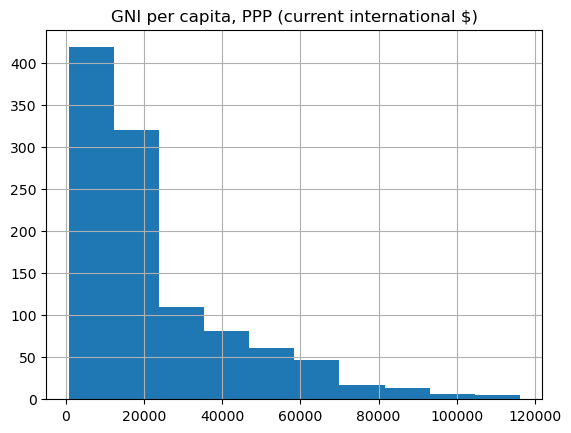

In [13]:
df.hist()

In [14]:
outlier_vars = [GNI]
df = remove_outliers_iqr(df, outlier_vars)

(1024, 2)


array([[<Axes: title={'center': 'GNI per capita, PPP (current international $)'}>]],
      dtype=object)

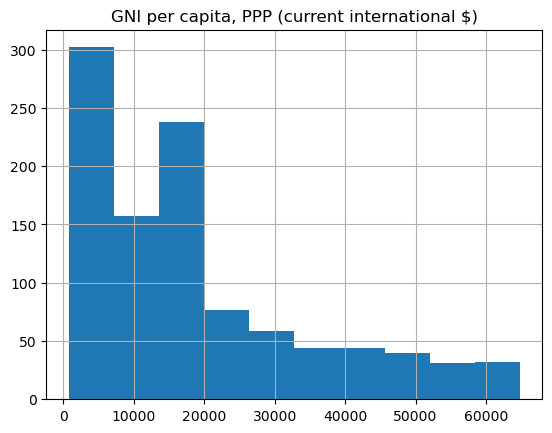

In [15]:
df.hist()

In [16]:
X = df[[GNI]]
X_scaled = scale_robust(X)
X_scaled

array([[-0.59645205],
       [-0.07840218],
       [-0.04267461],
       ...,
       [ 0.        ],
       [-0.55377745],
       [-0.55377745]], shape=(1024, 1))

In [17]:
# Construct a kmean clustering model
from sklearn.cluster import KMeans

def Kmean_cluster(k):
    selected_k = k  # number of resulting clusters
    selected_n_init = 15    # number of times the k-means algorithm is run with different centroid seeds
    model = KMeans(n_clusters=selected_k, n_init=selected_n_init, random_state=23)   
    
    X_clusters_Kmean = model.fit_predict(X_scaled)
    return X_clusters_Kmean
#######################################################
    
# Performance Evaluation
def cluster_eva(X_scaled, X_clusters_Kmean):
    silhouette, db, dunn, ch = evaluate_clustering(X_scaled, X_clusters_Kmean)
    print('Selected k: ', k)
    print('Silhouette Index: ', silhouette)
    print('Davies-Bouldin Index: ', db)
    print('Dunn Index: ', dunn)
    print('CH Index: ', ch)

for k in range(2, 6):
    cluster_eva(X_scaled, Kmean_cluster(k))

X_clusters_Kmean = Kmean_cluster(5)

Selected k:  2
Silhouette Index:  0.7040664328152938
Davies-Bouldin Index:  0.4603358671304996
Dunn Index:  0.8748253038139184
CH Index:  3197.0709942765166
Selected k:  3
Silhouette Index:  0.591835267384506
Davies-Bouldin Index:  0.5239961540658599
Dunn Index:  0.42804098443755534
CH Index:  3561.2809512707704
Selected k:  4
Silhouette Index:  0.6403433062968173
Davies-Bouldin Index:  0.46417069529189847
Dunn Index:  0.48385173348308763
CH Index:  5318.905266215587
Selected k:  5
Silhouette Index:  0.6542297750811453
Davies-Bouldin Index:  0.43626088217469833
Dunn Index:  0.669382577035961
CH Index:  7176.324168339831


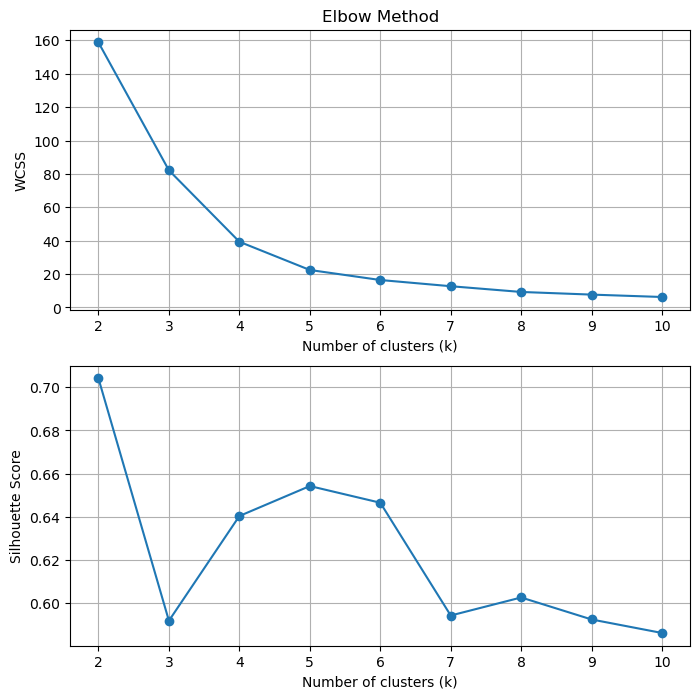

In [18]:
# Construct elbow curve and silhoulette curve to help choose value of k

from sklearn.metrics import silhouette_score

wcss = []
silhouette_scores = []

k_range = range(2, 11)  # silhouette is undefined for k=1

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=23)
    temp_X_clusters = kmeans.fit_predict(X_scaled)
    
    # Elbow (WCSS)
    wcss.append(kmeans.inertia_)
    
    # Silhouette
    silhouette = silhouette_score(X_scaled, temp_X_clusters)
    silhouette_scores.append(silhouette)

fig, axes = plt.subplots(2, 1, figsize=(8, 8))

axes[0].plot(k_range, wcss, marker='o')
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("WCSS")
axes[0].set_title("Elbow Method")
axes[0].grid(True)

axes[1].plot(k_range, silhouette_scores, marker='o')
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].grid(True)
#axes[1].set_title("Silhouette Score vs Number of Clusters")

plt.savefig('../src/elbow_n_silhouette.png', dpi=300, bbox_inches='tight')

plt.show()

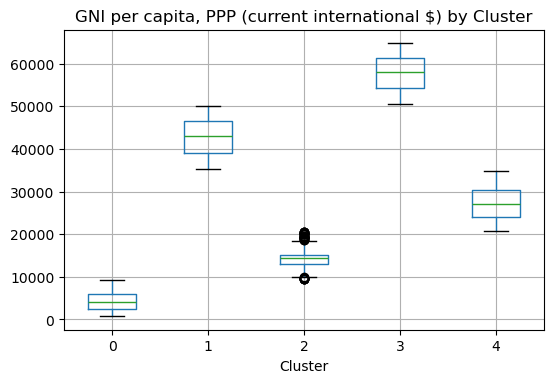

In [19]:
create_feature_boxplots(X, X_clusters_Kmean)

In [20]:
df['Kmean_cluster'] = X_clusters_Kmean
df

,Country Name,"GNI per capita, PPP (current international $)",Kmean_cluster
0,Afghanistan,2360.0,0
1,Albania,12800.0,2
2,Algeria,13520.0,2
3,American Samoa,14380.0,2
4,Andorra,14380.0,2
...,...,...,...
1075,Virgin Islands (U.S.),14380.0,2
1076,West Bank and Gaza,6800.0,0
1077,"Yemen, Rep.",14380.0,2
1078,Zambia,3220.0,0


In [21]:
merge_keys = ['Country Name', GNI]

orig_df_dd = orig_df.drop_duplicates(subset=merge_keys)

dfm = pd.merge(df, orig_df_dd, how='left', on=merge_keys)
print(dfm.shape)
dfm

(1024, 84)


,Country Name,"GNI per capita, PPP (current international $)",Kmean_cluster,Year,Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)",Arable land (% of land area),Cereal yield (kg per hectare),Crop production index (2014-2016 = 100),Fertilizer consumption (kilograms per hectare of arable land),...,High-technology exports (% of manufactured exports),High-technology exports (current US$),Medium and high-tech exports (% manufactured exports),Merchandise exports (current US$),Merchandise imports (current US$),Merchandise trade (% of GDP),"Contributing family workers, female (% of female employment) (modeled ILO estimate)","Contributing family workers, male (% of male employment) (modeled ILO estimate)",Region,ThirdWorld
0,Afghanistan,2360.0,0,2017,58.12,26.42,11.80,2091.4,99.210,20.45,...,6.23,86113314.5,2.120000,7.230000e+08,7.065000e+09,41.53,62.58,12.20,South Asia,Yes
1,Albania,12800.0,2,2017,42.86,19.02,22.34,4813.0,105.840,99.81,...,0.09,1118611.0,3.560000,2.292000e+09,5.271000e+09,58.09,29.97,17.04,Eastern Europe,No
2,Algeria,13520.0,2,2017,17.36,11.03,3.14,990.3,104.400,20.84,...,0.96,9028313.0,3.950000,3.519100e+10,4.605900e+10,42.79,2.33,1.70,Africa,No
3,American Samoa,14380.0,2,2017,13.90,6.59,4.65,3052.7,103.615,41.67,...,6.23,86113314.5,33.202833,3.970000e+08,5.950000e+08,162.09,4.25,1.99,Australia and Oceanea,No
4,Andorra,14380.0,2,2017,40.04,0.56,1.74,3052.7,103.615,90.00,...,23.25,24238350.0,33.202833,1.180000e+08,1.478000e+09,53.20,4.25,1.99,Western Europe,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1019,Virgin Islands (U.S.),14380.0,2,2017,11.43,6.59,2.86,3052.7,103.615,98.92,...,6.23,86113314.5,33.202833,6.608000e+09,9.121000e+09,53.03,0.38,0.21,North America,No
1020,West Bank and Gaza,6800.0,0,2021,64.93,6.32,6.95,2251.9,117.310,371.97,...,1.60,14531924.0,15.110000,6.608000e+09,9.121000e+09,53.03,8.55,3.44,Middle East,No
1021,"Yemen, Rep.",14380.0,2,2017,44.42,26.96,2.20,699.0,92.490,12.73,...,6.23,86113314.5,0.560000,4.180000e+08,3.088000e+09,13.06,39.15,9.62,Middle East,Yes
1022,Zambia,3220.0,0,2021,32.07,3.00,5.11,2525.0,136.310,63.90,...,0.95,10218867.0,28.800000,1.010100e+10,6.435000e+09,74.84,4.87,2.36,Africa,Yes


In [22]:
dfm.columns

Index(['Country Name', 'GNI per capita, PPP (current international $)',
       'Kmean_cluster', 'Year', 'Agricultural land (% of land area)',
       'Agriculture, forestry, and fishing, value added (% of GDP)',
       'Arable land (% of land area)', 'Cereal yield (kg per hectare)',
       'Crop production index (2014-2016 = 100)',
       'Fertilizer consumption (kilograms per hectare of arable land)',
       'Food production index (2014-2016 = 100)',
       'Forest area (% of land area)', 'Forest area (sq. km)',
       'Land area (sq. km)', 'Livestock production index (2014-2016 = 100)',
       'Permanent cropland (% of land area)', 'Rural population',
       'Rural population (% of total population)', 'Surface area (sq. km)',
       'Access to electricity (% of population)',
       'Annual freshwater withdrawals, total (% of internal resources)',
       'Mortality rate, under-5 (per 1,000 live births)',
       'Population growth (annual %)', 'Population, total',
       'Renewable ener

In [23]:
selected_vars = [
                'Rural population (% of total population)',
                'Agricultural land (% of land area)',
                'Crop production index (2014-2016 = 100)', 
                'Merchandise trade (% of GDP)',
                'Access to electricity (% of population)',
                ]

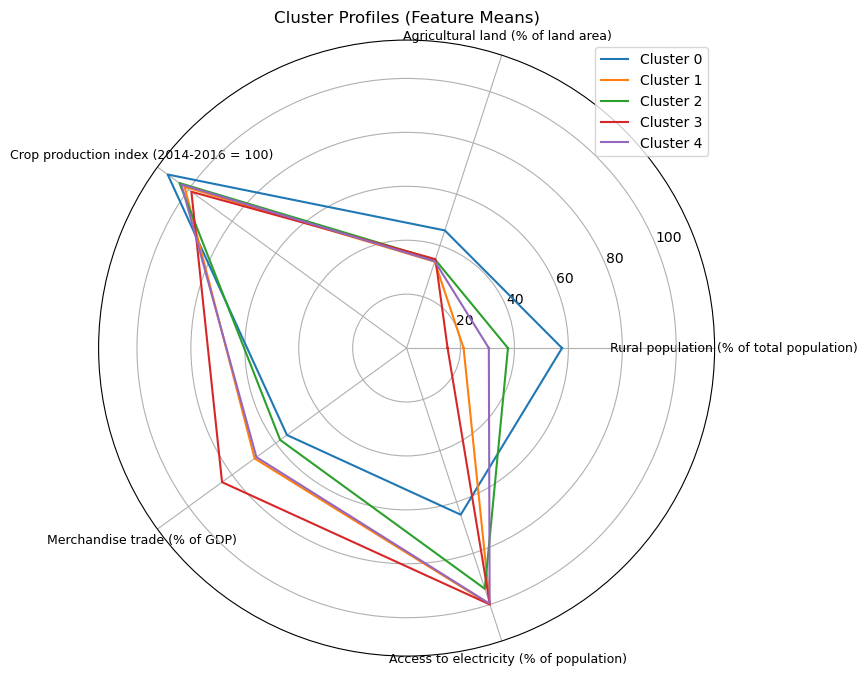

In [24]:
create_radar_graph(dfm[selected_vars], X_clusters_Kmean, (8, 8))

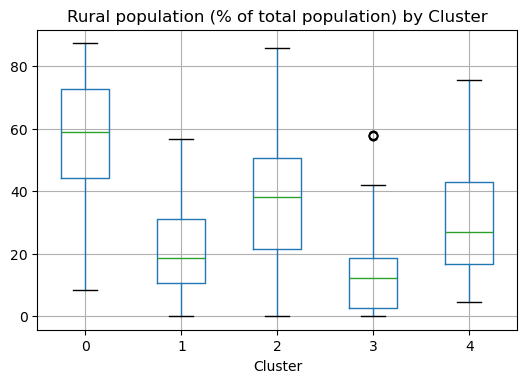

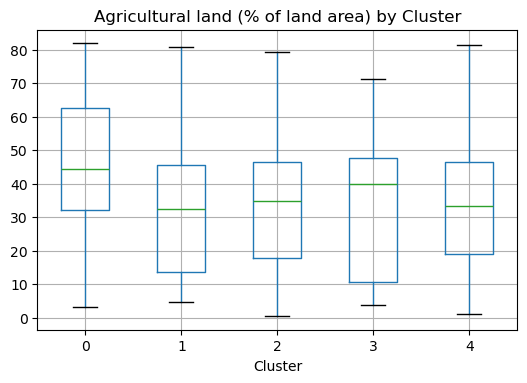

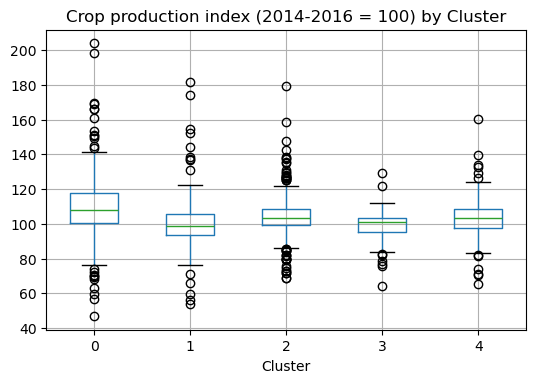

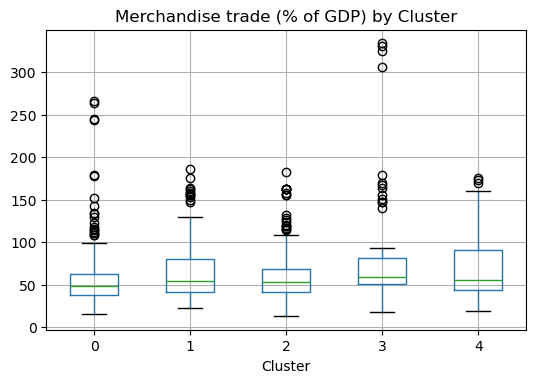

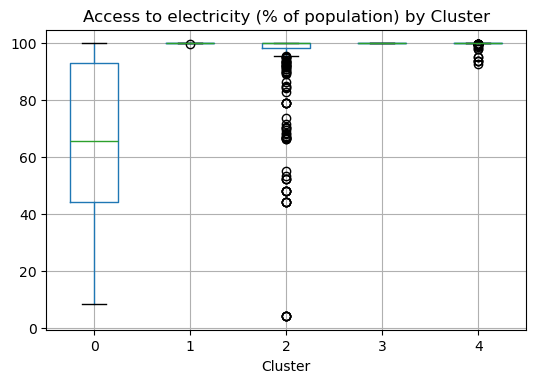

In [25]:
create_feature_boxplots(dfm[selected_vars], X_clusters_Kmean)

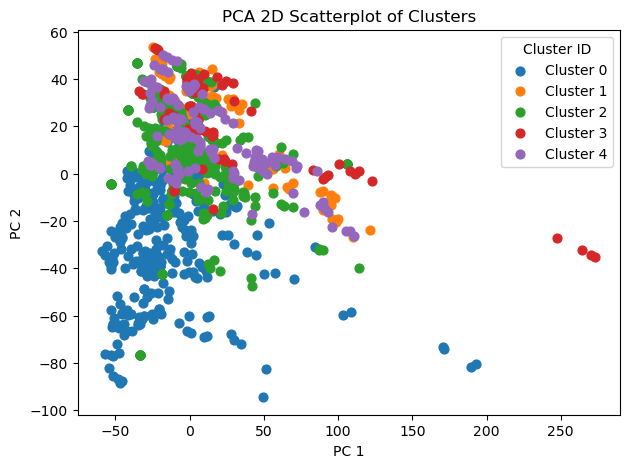

In [26]:
create_pca_scatterplot(dfm[selected_vars], X_clusters_Kmean)